In [21]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import confusion_matrix, classification_report

In [22]:
# -----------------------------
# 1) Load dataset from local CSV files
# -----------------------------
import pandas as pd

# Load the training and testing datasets from local CSV files into pandas DataFrames
train_df = pd.read_csv("fashion-mnist_train.csv")
test_df = pd.read_csv("fashion-mnist_test.csv")

# Extract the 'label' column to use as ground truth targets
y_train = train_df['label'].values
# Drop the 'label' column to isolate pixel values and reshape flattened pixels (784) back to 2D image shapes (28, 28)
x_train = train_df.drop(columns=['label']).values.reshape(-1, 28, 28)

# Extract test set labels
y_test = test_df['label'].values
# Isolate and reshape test set pixel values to match training dimensions
x_test = test_df.drop(columns=['label']).values.reshape(-1, 28, 28)

# Define human-readable names corresponding to clothing integer categories (0-9)
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

In [23]:
# -----------------------------
# 2) Preprocessing
# Normalize (0-255) -> (0-1)
# Reshape to (28,28,1) for CNN
# -----------------------------
# Convert integer pixel intensities to float32 and divide by 255.0 to normalize range to [0.0, 1.0]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add a single grayscale channel dimension at the end to match expected Conv2D inputs: (samples, height, width, channels)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

In [24]:
# -----------------------------
# 3) Build CNN model
# -----------------------------
# Instantiate a Sequential container to build the linear stack of layers
model = keras.Sequential([
    # Define the input layer with the expected shape of (28, 28, 1)
    layers.Input(shape=(28, 28, 1)),

    # First Conv2D layer with 32 filters, 3x3 kernel size, Relu activation, and same padding to keep spatial size
    layers.Conv2D(32, (3, 3), activation="relu", padding='same'),
    # BatchNormalization normalizes activations to reduce covariate shift and speed up training
    layers.BatchNormalization(),
    # MaxPooling2D downsamples inputs by 2x2, reducing parameters and building translation invariance
    layers.MaxPooling2D((2, 2)),
    # Dropout regularizes the layer by randomly zeroing out 30% of connections to prevent overfitting
    layers.Dropout(0.3),

    # Second Conv2D layer with 64 filters to capture more complex visual patterns
    layers.Conv2D(64, (3, 3), activation="relu", padding='same'),
    # Normalize intermediate feature maps of the second convolution layer
    layers.BatchNormalization(),
    # Downsample features by another 2x2 factor
    layers.MaxPooling2D((2, 2)),
    # Randomly deactivate 30% of feature map activations
    layers.Dropout(0.3),

    # Flatten maps from 2D matrices into 1D vectors to connect to dense classification layers
    layers.Flatten(),
    # Fully-connected dense layer with 128 hidden units and ReLU activation for non-linear reasoning
    layers.Dense(128, activation="relu"),
    # Normalize features after dense mapping
    layers.BatchNormalization(),
    # Randomly deactivate 30% of intermediate dense features to reduce overfitting risk
    layers.Dropout(0.3),
    # Output layer with 10 softmax-activated units yielding probability distributions across class labels
    layers.Dense(10, activation="softmax")
])

In [ ]:
# -----------------------------
# 4) Compile
# -----------------------------
# Compile the network specifying the optimizer, categorical loss calculation method, and evaluation metric
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy", # It measures how "wrong" the model's predictions are
    metrics=["accuracy"]
)

# Display a structural summary of the model layers and parameters
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,538 (1.61 MB)

 Trainable params: 422,090 (1.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [26]:
# Import the EarlyStopping callback directly from keras callbacks
from tensorflow.keras.callbacks import EarlyStopping
# Set up early stopping to monitor validation loss, stopping after 3 epochs of stagnation and restoring best weights
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# -----------------------------
# 5) Train
# -----------------------------
# Train the model with a 20% validation split, 15 max epochs, a batch size of 64, and the early stopping callback
history = model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8347 - loss: 0.4671 - val_accuracy: 0.8523 - val_loss: 0.3822
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8776 - loss: 0.3384 - val_accuracy: 0.8990 - val_loss: 0.2798
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8916 - loss: 0.2991 - val_accuracy: 0.8875 - val_loss: 0.2884
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9005 - loss: 0.2727 - val_accuracy: 0.9038 - val_loss: 0.2847
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9041 - loss: 0.2607 - val_accuracy: 0.9168 - val_loss: 0.2481
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9103 - loss: 0.2455 - val_accuracy: 0.9093 - val_loss: 0.2602
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9128 - loss: 0.2342 - val_accuracy: 0.9002 - val_loss: 0.2806
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9168 - loss: 0.2252 - val_accuracy: 0

In [27]:
# -----------------------------
# 6) Evaluate on test data
# -----------------------------
# Calculate testing loss and accuracy on unseen test data
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print("\n--- Test Results ---")
# Output the final test accuracy metric
print(f"Test Accuracy: {test_acc:.4f}")
# Output the final test loss metric
print(f"Test Loss    : {test_loss:.4f}")


--- Test Results ---
Test Accuracy: 0.9304
Test Loss    : 0.1990


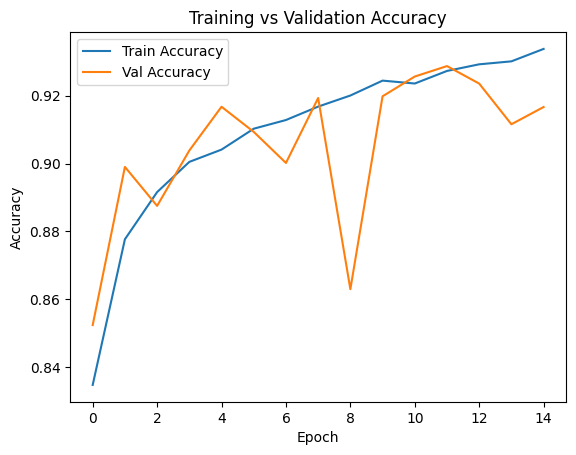

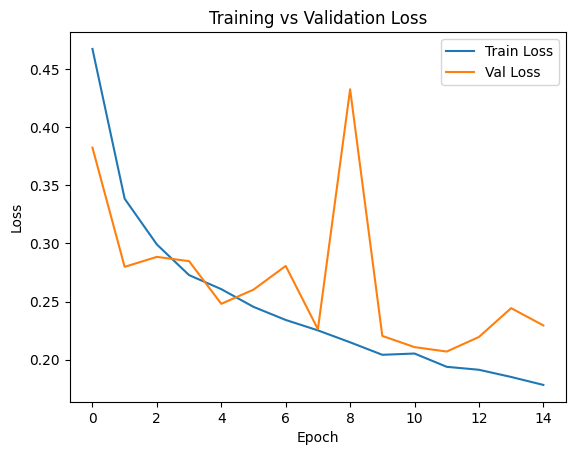

In [28]:
# -----------------------------
# 7) Plot Accuracy and Loss graphs
# -----------------------------
# Initialize a new figure canvas to plot accuracy metrics
plt.figure()
# Plot training accuracy across epochs
plt.plot(history.history["accuracy"], label="Train Accuracy")
# Plot validation accuracy across epochs
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

# Initialize a new figure canvas to plot loss metrics
plt.figure()
# Plot training loss across epochs
plt.plot(history.history["loss"], label="Train Loss")
# Plot validation loss across epochs
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [29]:
# -----------------------------
# 8) Confusion Matrix + Report
# -----------------------------
# Generate class probability distributions on unseen test images
y_pred_probs = model.predict(x_test, verbose=0)
# Extract the target index containing the highest prediction probability for each sample
y_pred = np.argmax(y_pred_probs, axis=1)

# Generate a raw confusion matrix to tabulate misclassifications
cm = confusion_matrix(y_test, y_pred)
print("\n--- Classification Report ---")
# Generate and display a classification report containing precision, recall, and F1 metrics for each class
print(classification_report(y_test, y_pred, target_names=class_names))

print("\n--- Confusion Matrix ---")
# Print the raw values of correct vs incorrect category predictions
print(cm)


--- Classification Report ---
              precision    recall  f1-score   support

 T-shirt/top       0.89      0.88      0.89      1000
     Trouser       1.00      0.99      0.99      1000
    Pullover       0.95      0.84      0.89      1000
       Dress       0.90      0.96      0.93      1000
        Coat       0.88      0.91      0.90      1000
      Sandal       1.00      0.97      0.99      1000
       Shirt       0.79      0.82      0.80      1000
     Sneaker       0.96      0.97      0.96      1000
         Bag       0.99      0.98      0.99      1000
  Ankle boot       0.96      0.98      0.97      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000


--- Confusion Matrix ---
[[883   0   9  25   1   0  80   0   2   0]
 [  0 988   0  10   0   1   1   0   0   0]
 [ 16   0 837  20  64   0  62   0   1   0]
 [  5   2   1 964  17   0  11   0   0   0]
 [  0   0  1

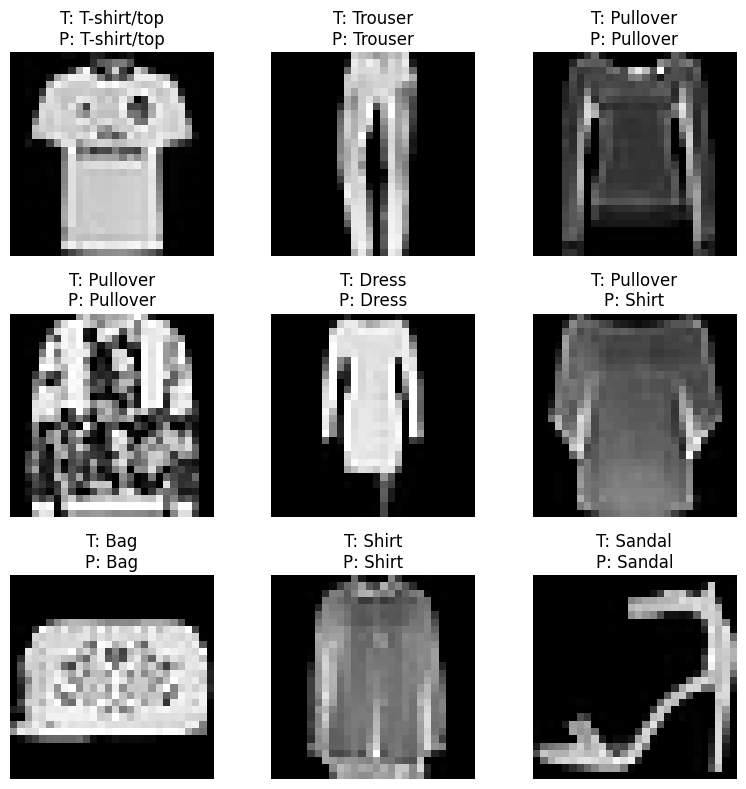

In [30]:
# -----------------------------
# 9) Show predictions for 9 sample images
# -----------------------------
# Allocate an 8x8 canvas to plot predicted samples
plt.figure(figsize=(8, 8))
for i in range(9):
    # Place current image subplot inside a 3x3 visual grid
    plt.subplot(3, 3, i + 1)
    # Remove the grayscale channel dimension and plot the 2D image matrix
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    # Title each subplot showing Ground Truth/Target (T) vs Model Prediction (P)
    plt.title(f"T: {class_names[y_test[i]]}\nP: {class_names[y_pred[i]]}")
    # Hide the subplot coordinate axis lines for aesthetic clarity
    plt.axis("off")
# Adjust layout parameters to prevent label overlapping
plt.tight_layout()
plt.show()